Mounted at /content/drive
[001] train=375.38 | val=649.98
[010] train=369.75 | val=639.86
[020] train=363.28 | val=628.96
[030] train=356.93 | val=617.24
[040] train=349.32 | val=603.50
[050] train=339.80 | val=585.98
[060] train=327.83 | val=563.58
[070] train=312.54 | val=535.90
[080] train=294.81 | val=502.67
[090] train=275.49 | val=464.29
[100] train=251.55 | val=421.56
[110] train=232.82 | val=375.84
[120] train=208.55 | val=329.41
[130] train=180.38 | val=284.82
[140] train=158.62 | val=245.21
[150] train=138.47 | val=212.54


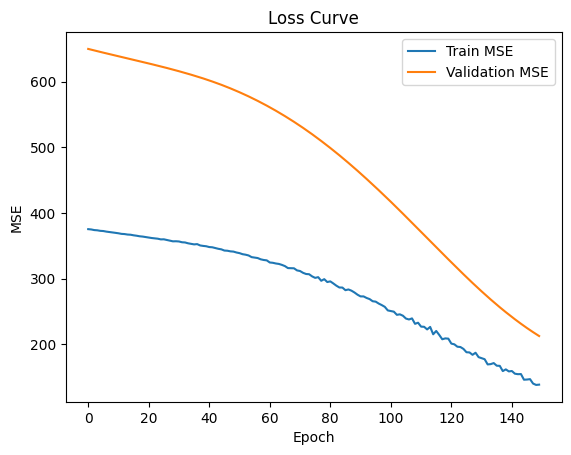

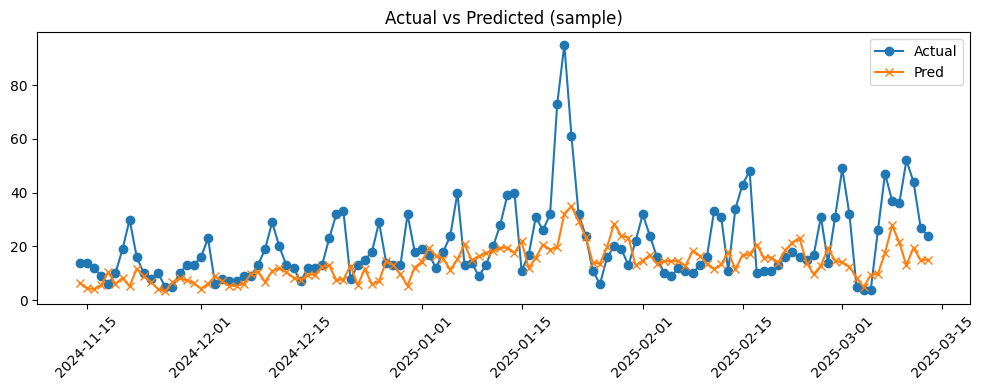

In [1]:
# ==========================================
# PyTorch 회귀: 미세먼지 예측 모델 전체 코드
# ==========================================

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error


from google.colab import drive
drive.mount('/content/drive')

# 데이터 파일 경로
CSV_PATH = '/content/drive/MyDrive/data/pm25.csv'


# ---------- 1) 데이터 읽기 및 전처리 ----------
def read_csv_robust(path):
    try:
        return pd.read_csv(path)
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding='cp949')

df = read_csv_robust(CSV_PATH)
df.columns = df.columns.str.lower()
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# 수치형 변환
for c in ['pm25', 'avg_temp', 'humidity', 'wind_speed', 'rainfall', 'wind_dir_deg']:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

# 풍향을 sin, cos 값으로 변환
if 'wind_dir_deg' in df.columns:
    theta = np.deg2rad(df['wind_dir_deg'].clip(0, 360))
    df['wind_sin'] = np.sin(theta)
    df['wind_cos'] = np.cos(theta)
else:
    df['wind_sin'] = 0.0
    df['wind_cos'] = 0.0

# 강수량 결측값 처리 및 핵심 변수 결측 제거
if 'rainfall' in df.columns:
    df['rainfall'] = df['rainfall'].fillna(0)

core = [c for c in ['pm25', 'avg_temp', 'humidity', 'wind_speed', 'rainfall'] if c in df.columns]
df = df.dropna(subset=core).reset_index(drop=True)

# 시계열 특성을 위한 파생 변수 생성
df['pm25_t1'] = df['pm25'].shift(1)
df['pm25_t7'] = df['pm25'].shift(7)
df['dow'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month

feat_cols = [
    c for c in [
        'avg_temp', 'humidity', 'wind_speed', 'rainfall',
        'wind_sin', 'wind_cos', 'pm25_t1', 'pm25_t7',
        'dow', 'month'
    ] if c in df.columns
]

df = df.dropna(subset=['pm25'] + feat_cols).reset_index(drop=True)

X = df[feat_cols].values.astype(np.float32)
y = df['pm25'].values.astype(np.float32)

# ---------- 2) 시간기반 분할 및 표준화 ----------
split = int(len(df) * 0.8)
X_tr, X_val = X[:split], X[split:]
y_tr, y_val = y[:split], y[split:]
dates_val = df['date'].iloc[split:].reset_index(drop=True)

scaler = StandardScaler()
X_tr = scaler.fit_transform(X_tr)
X_val = scaler.transform(X_val)

X_tr = torch.tensor(X_tr, dtype=torch.float32)
y_tr = torch.tensor(y_tr, dtype=torch.float32).view(-1, 1)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

# ---------- 3) 모델 구성 ----------
class MLP(nn.Module):
    def __init__(self, in_dim, p=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 32),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.net(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MLP(X_tr.shape[1], p=0.3).to(device)

X_tr = X_tr.to(device)
y_tr = y_tr.to(device)
X_val = X_val.to(device)
y_val = y_val.to(device)

# ---------- 4) 학습 설정 ----------
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

EPOCHS = 150
PATIENCE = 15
wait = 0
best_val = math.inf
best_state = None

train_mse = []
val_mse = []

# ---------- 5) 학습 수행 ----------
for ep in range(1, EPOCHS + 1):
    # 훈련 단계
    model.train()
    pred = model(X_tr)
    loss = criterion(pred, y_tr)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # 검증 단계
    model.eval()
    with torch.no_grad():
        v_pred = model(X_val)
        v_loss = criterion(v_pred, y_val).item()

    # 손실 기록 및 학습률 조정
    train_mse.append(loss.item())
    val_mse.append(v_loss)
    scheduler.step(v_loss)

    # 최적 모델 저장
    if v_loss < best_val - 1e-6:
        best_val = v_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1

    # 진행 상황 출력
    if ep % 10 == 0 or ep == 1:
        print(f'[{ep:03d}] train={loss.item():.2f} | val={v_loss:.2f}')

    # 조기 종료
    if wait >= PATIENCE:
        print(f'Early stopping at epoch {ep} (best val MSE={best_val:.2f})')
        break

# 최적 모델 상태 복원
if best_state is not None:
    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

# ---------- 6) 학습 결과 시각화 ----------
plt.plot(train_mse, label='Train MSE')
plt.plot(val_mse, label='Validation MSE')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()

# ---------- 7) 검증 성능 및 예측 결과 ----------
model.eval()
with torch.no_grad():
    y_pred = model(X_val).cpu().numpy().ravel()

y_true = y_val.cpu().numpy().ravel()

n_show = min(120, len(y_pred))
plt.figure(figsize=(10, 4))
plt.plot(dates_val[:n_show], y_true[:n_show], label='Actual', marker='o')
plt.plot(dates_val[:n_show], y_pred[:n_show], label='Pred', marker='x')
plt.title('Actual vs Predicted (sample)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()